In [1]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv("Crop_recommendation.csv")
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Dataset Shape: (2200, 8)
Missing Values: N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


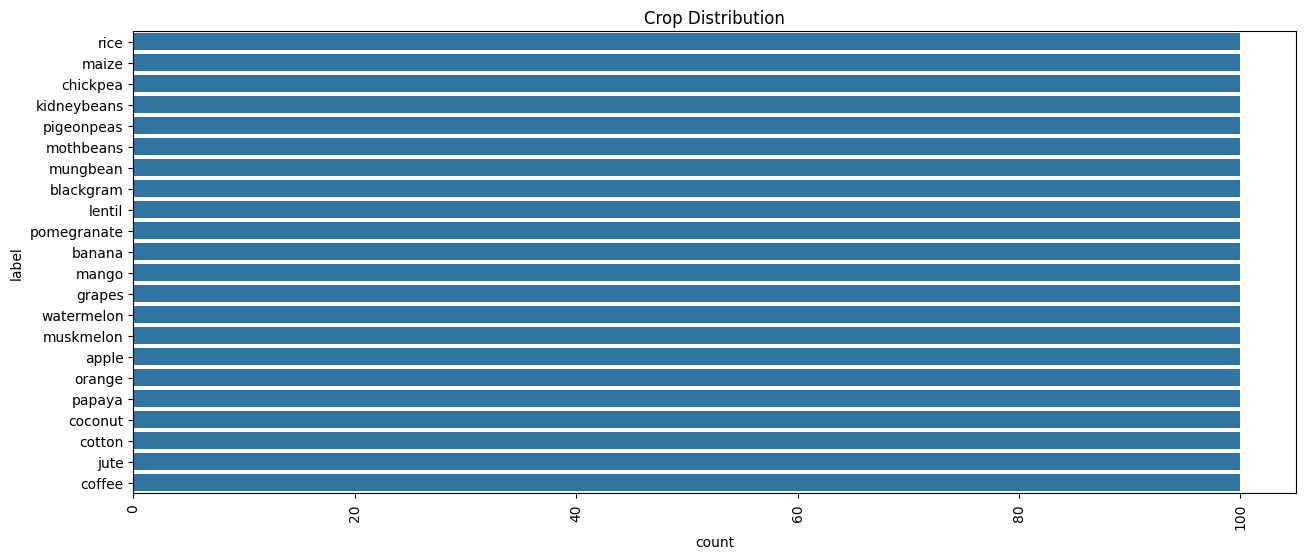

In [3]:
# Check shape
print("Dataset Shape:", data.shape)

# Check missing values
print("Missing Values:", data.isnull().sum())

# Crop distribution
plt.figure(figsize=(15,6))
sns.countplot(data['label'])
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()


In [4]:
# Features and Target
X = data.drop('label', axis=1)
y = data['label']

# Encode target crops
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (1760, 7)
Test Shape: (440, 7)


In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


In [7]:
import pickle

# Save model
pickle.dump(model, open('model.pkl', 'wb'))

# Save label encoder
pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100, "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 99.31818181818181 %

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00   

In [9]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    prediction = model.predict(input_data)
    crop = le.inverse_transform(prediction)[0]
    return crop

# Example test
print("Recommended Crop:", predict_crop(90, 40, 40, 20, 80, 6.5, 200))


c:\Crop Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Recommended Crop: rice


In [10]:
# Input from user
N = int(input("Nitrogen value: "))
P = int(input("Phosphorous value: "))
K = int(input("Potassium value: "))
temperature = float(input("Temperature (°C): "))
humidity = float(input("Humidity (%): "))
ph = float(input("pH value: "))
rainfall = float(input("Rainfall (mm): "))

print("🌱 Recommended Crop:", predict_crop(N, P, K, temperature, humidity, ph, rainfall))
15

c:\Crop Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


🌱 Recommended Crop: maize


15